In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sports-classification/EfficientNetB0-100-(224 X 224)- 98.40.h5
/kaggle/input/sports-classification/sports.csv
/kaggle/input/sports-classification/valid/bobsled/5.jpg
/kaggle/input/sports-classification/valid/bobsled/1.jpg
/kaggle/input/sports-classification/valid/bobsled/4.jpg
/kaggle/input/sports-classification/valid/bobsled/3.jpg
/kaggle/input/sports-classification/valid/bobsled/2.jpg
/kaggle/input/sports-classification/valid/hurdles/5.jpg
/kaggle/input/sports-classification/valid/hurdles/1.jpg
/kaggle/input/sports-classification/valid/hurdles/4.jpg
/kaggle/input/sports-classification/valid/hurdles/3.jpg
/kaggle/input/sports-classification/valid/hurdles/2.jpg
/kaggle/input/sports-classification/valid/snow boarding/5.jpg
/kaggle/input/sports-classification/valid/snow boarding/1.jpg
/kaggle/input/sports-classification/valid/snow boarding/4.jpg
/kaggle/input/sports-classification/valid/snow boarding/3.jpg
/kaggle/input/sports-classification/valid/snow boarding/2.jpg
/kaggl

In [4]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


1. DataLoader
2. Transforms
3. Model Class
4. Train

In [6]:
TRANSFORMS = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(45),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.RandomAutocontrast(),
])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224)),
])
dataset_train = ImageFolder(
    "/kaggle/input/sports-classification/train",
    transform = TRANSFORMS
)
dataset_test = ImageFolder(
    "/kaggle/input/sports-classification/test",
    transform = TRANSFORMS
)

In [16]:
batch_size = 30
dataloader_train = DataLoader(
    dataset_train,
    shuffle = True,
    batch_size=batch_size
)
#image, label = next(iter(dataloader_train))
#plt.imshow(image.squeeze().permute(1,2,0))
#print(image.shape)
#print(label)
dataloader_test = DataLoader(
    dataset_train,
    shuffle = True,
    batch_size=batch_size
)

In [8]:
class Net(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.AdaptiveAvgPool2d((1, 1)) ,
            nn.Flatten(),
        )
        self.classifier = nn.Linear(64,num_classes)
    def forward(self,x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [13]:
net = Net(num_classes = 100)
net.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr = 0.001)

for epoch in range(10):
    for image,labels in dataloader_train:
        image, labels = image.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs = net(image)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()

In [21]:
from torchmetrics import Recall,Precision

recall_per_class = Recall(task="multiclass", num_classes=100, average=None).to(device)
metric_precision = Precision(  task="multiclass", num_classes=100, average=None).to(device)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        images, labels = images.to(device),labels.to(device)
        outputs = net(images)
        _, preds = torch.max(outputs,1)
        metric_precision(preds,labels)
        recall_per_class(preds,labels)


NameError: name 'metric_recall' is not defined

In [24]:
precision = metric_precision.compute()
recall = recall_per_class.compute()

In [25]:
print(precision)
print(recall)

tensor([0.2105, 0.1053, 0.0000, 0.3088, 0.1172, 0.2706, 0.1705, 0.2059, 0.1217,
        0.1304, 0.1157, 0.4583, 0.0000, 0.1358, 0.1111, 0.2222, 0.2929, 0.0811,
        0.1391, 0.0000, 0.1119, 0.2105, 0.2146, 0.4793, 0.2011, 0.2488, 0.2836,
        0.2179, 0.3000, 0.3617, 0.2212, 0.1351, 0.1344, 0.1034, 0.0411, 0.2310,
        0.1735, 0.1032, 0.0472, 0.2000, 0.1429, 0.2166, 0.1579, 0.2650, 0.0000,
        0.1923, 0.1277, 0.1811, 0.2182, 0.2931, 0.1463, 0.2235, 0.3049, 0.3191,
        0.1772, 0.1634, 0.0000, 0.1746, 0.1200, 0.3818, 0.0800, 0.4286, 0.1509,
        0.0526, 0.3111, 0.0000, 0.2549, 0.1475, 0.1429, 0.0549, 0.2390, 0.1267,
        0.2374, 0.1111, 0.3736, 0.1132, 0.0303, 0.2000, 0.1849, 0.0580, 0.1724,
        0.2000, 0.1479, 0.2533, 0.2633, 0.2911, 0.2362, 0.0357, 0.2679, 0.1026,
        0.1500, 0.3571, 0.1313, 0.2676, 0.4342, 0.4326, 0.0909, 0.1950, 0.0952,
        0.2432], device='cuda:0')
tensor([0.0357, 0.0179, 0.0000, 0.4242, 0.1504, 0.1565, 0.1220, 0.0402, 0.1657,
      

In [26]:
{  k: recall[v].item() for k, v in dataset_test.class_to_idx.items()}

{'air hockey': 0.0357142873108387,
 'ampute football': 0.01785714365541935,
 'archery': 0.0,
 'arm wrestling': 0.42424243688583374,
 'axe throwing': 0.1504424810409546,
 'balance beam': 0.15646257996559143,
 'barell racing': 0.12195122241973877,
 'baseball': 0.04022988677024841,
 'basketball': 0.16568046808242798,
 'baton twirling': 0.1388888955116272,
 'bike polo': 0.12727272510528564,
 'billiards': 0.45517241954803467,
 'bmx': 0.0,
 'bobsled': 0.07971014827489853,
 'bowling': 0.02500000037252903,
 'boxing': 0.5344827771186829,
 'bull riding': 0.38926175236701965,
 'bungee jumping': 0.04800000041723251,
 'canoe slamon': 0.25609755516052246,
 'cheerleading': 0.0,
 'chuckwagon racing': 0.2750000059604645,
 'cricket': 0.03100775182247162,
 'croquet': 0.41791045665740967,
 'curling': 0.41134750843048096,
 'disc golf': 0.28455284237861633,
 'fencing': 0.39259257912635803,
 'field hockey': 0.6178343892097473,
 'figure skating men': 0.53125,
 'figure skating pairs': 0.09933774918317795,
 'fi

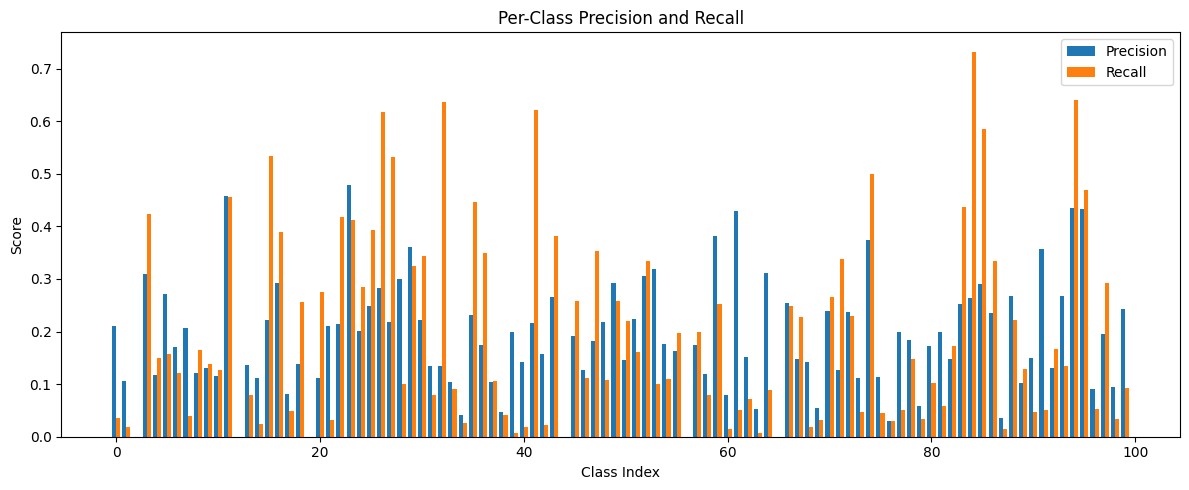

In [32]:

num_classes = len(precision)
classes = np.arange(num_classes)
precision,recall = precision.to('cpu'),recall.to('cpu')
plt.figure(figsize=(12, 5))

plt.bar(classes - 0.2, precision, width=0.4, label="Precision")
plt.bar(classes + 0.2, recall, width=0.4, label="Recall")

plt.xlabel("Class Index")
plt.ylabel("Score")
plt.title("Per-Class Precision and Recall")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
from torchmetrics import ConfusionMatrix

confmat_metric = ConfusionMatrix(task="multiclass", num_classes=100).to(device)

net.eval()
confmat_metric.reset()

with torch.no_grad():
    for images, labels in dataloader_test:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        preds = torch.argmax(outputs, dim=1)
        confmat_metric.update(preds, labels)

confmat = confmat_metric.compute().cpu().numpy()

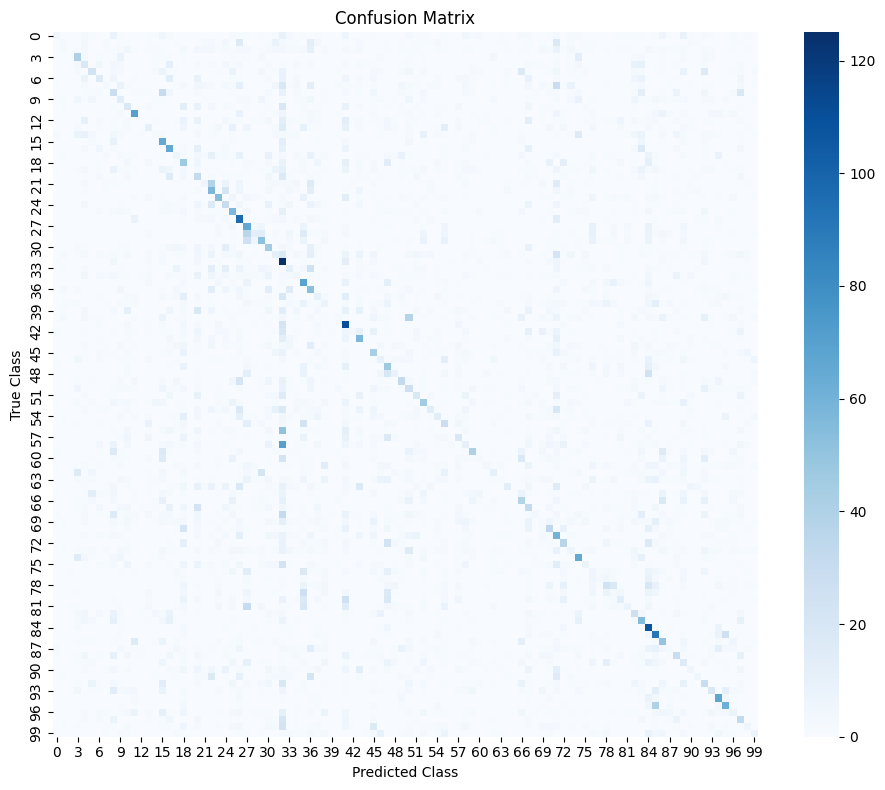

In [34]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(confmat, cmap="Blues", square=True, cbar=True)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()